Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classification Imbalance Check: 

Success
1    0.52
0    0.48
Name: proportion, dtype: float64
Summary of data:         Project_ID  Investment_Cost  Expected_Cashflow_Year1  \
count    50.00000     5.000000e+01             5.000000e+01   
mean     25.50000     2.508812e+06             1.019832e+06   
std      14.57738     1.250287e+06             5.953064e+05   
min       1.00000     1.232470e+05             6.266600e+04   
25%      13.25000     1.731652e+06             5.329580e+05   
50%      25.50000     2.685838e+06             1.037420e+06   
75%      37.75000     3.480671e+06             1.475176e+06   
max      50.00000     4.898669e+06             1.936222e+06   

       Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
count             5.000000e+01             5.000000e+01       50.000000   
mean              1.245896e+06          

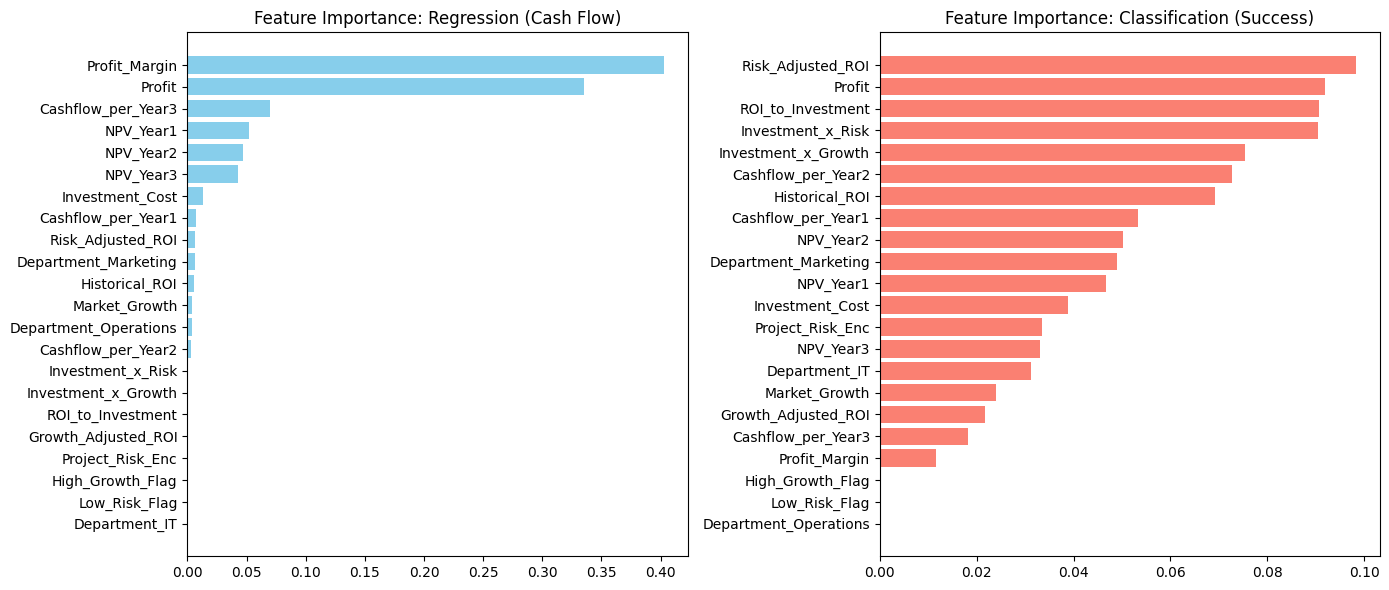

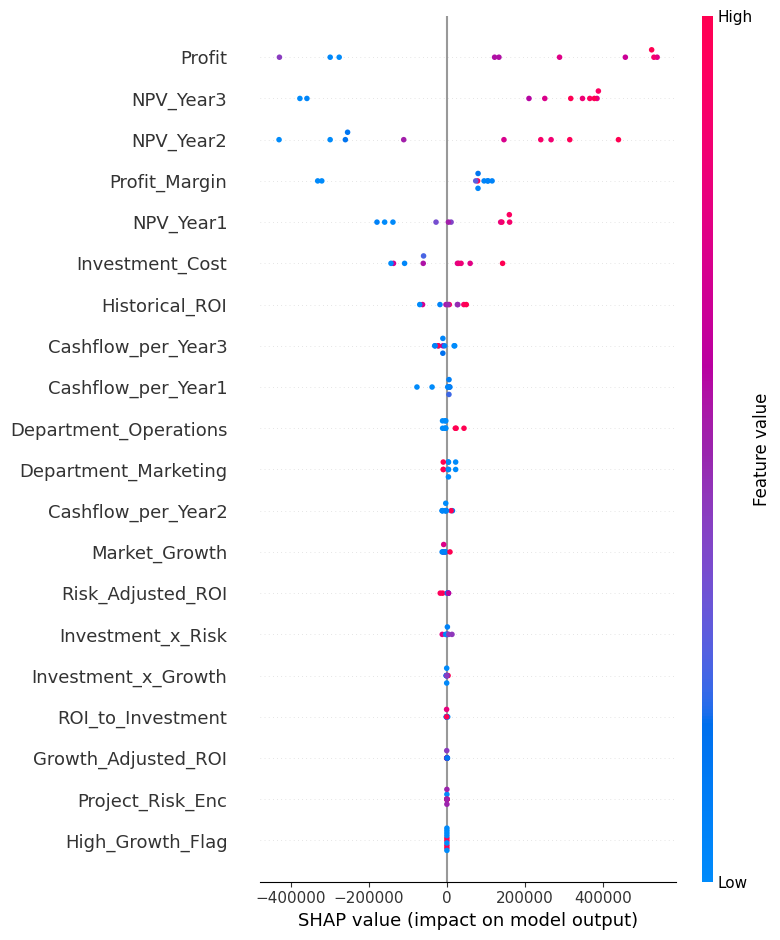

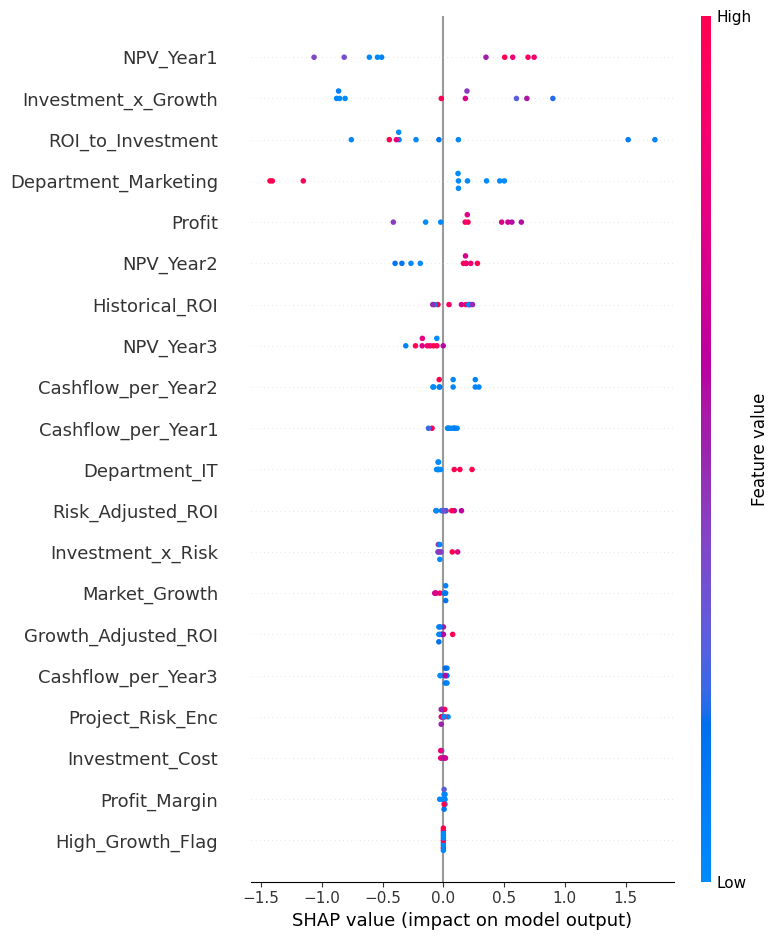

In [21]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, log_loss, mean_absolute_error, r2_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import shap

# ---- LOAD DATA ------
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ml-for-finance-project/corporate_projects.csv')

# Preprocessing
df_mod = df.copy()
print("Classification Imbalance Check: \n")
print(df_mod['Success'].value_counts(normalize=True))
print("Summary of data: ", df_mod.describe())

# col_dept = LabelEncoder()
# df_mod['Department_Enc'] = col_dept.fit_transform(df_mod['Department'])
df_mod = pd.get_dummies(df_mod, columns=['Department'], drop_first=True)

risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_mod['Project_Risk_Enc'] = df_mod['Project_Risk'].map(risk_map)

discount_rate = 0.1  # You can tune this (e.g., 8%, 10%, 12%)
# Year-wise discounted cashflows
df_mod['NPV_Year1'] = df_mod['Expected_Cashflow_Year1'] / ((1 + discount_rate) ** 1)
df_mod['NPV_Year2'] = df_mod['Expected_Cashflow_Year2'] / ((1 + discount_rate) ** 2)
df_mod['NPV_Year3'] = df_mod['Expected_Cashflow_Year3'] / ((1 + discount_rate) ** 3)

# Total NPV (final)
df_mod['NPV_Total'] = df_mod['NPV_Year1'] + df_mod['NPV_Year2'] + df_mod['NPV_Year3']

# Feature Engineering
df_mod['ROI_to_Investment'] = df_mod['Historical_ROI'] / (df_mod['Investment_Cost'] + 1)
df_mod['Cashflow_per_Year1'] = df_mod['NPV_Year1'] / (df_mod['Investment_Cost'] + 1)
df_mod['Cashflow_per_Year2'] = df_mod['NPV_Year2'] / (df_mod['Investment_Cost'] + 1)
df_mod['Cashflow_per_Year3'] = df_mod['NPV_Year3'] / (df_mod['Investment_Cost'] + 1)
df_mod['Growth_Adjusted_ROI'] = df_mod['Historical_ROI'] * df_mod['Market_Growth']
df_mod['Risk_Adjusted_ROI'] = df_mod['Historical_ROI'] / (1 + df_mod['Project_Risk_Enc'])
df_mod['Investment_x_Risk'] = df_mod['Investment_Cost'] * df_mod['Project_Risk_Enc']
df_mod['Investment_x_Growth'] = df_mod['Investment_Cost'] * df_mod['Market_Growth']
df_mod['Profit'] = df_mod['NPV_Total'] - df_mod['Investment_Cost']
df_mod['Profit_Margin'] = df_mod['Profit'] / (df_mod['Investment_Cost'] + 1)
df_mod['High_Growth_Flag'] = (df_mod['Market_Growth'] > df_mod['Market_Growth'].median()).astype(int)
df_mod['Low_Risk_Flag'] = (df_mod['Project_Risk_Enc'] == 0).astype(int)

drop_features =  [
            'Project_ID',
            'NPV_Total',
            'Success',
            'Project_Risk',
            'Expected_Cashflow_Year1',
            'Expected_Cashflow_Year2',
            'Expected_Cashflow_Year3'
            ]
X = df_mod.drop(drop_features, axis=1)
y_reg = df_mod['NPV_Total']
y_clf = df_mod['Success']

# ------- MODEL TRAINING ------
# Train-Test Split
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, shuffle=True
)

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

# 1. Regression: RandomForest
reg_rd_model = RandomForestRegressor(n_estimators=200, random_state=42)
reg_rd_model.fit(X_train, y_reg_train)
y_rd_reg_test_pred = reg_rd_model.predict(X_test)

# 2. Regression: XGBoost
reg_xgb_model = XGBRegressor(n_estimators=200, max_depth=10, learning_rate=0.05, random_state=42)
reg_xgb_model.fit(X_train, y_reg_train)
y_xgb_reg_test_pred = reg_xgb_model.predict(X_test)

# 4. Classification: RandomForest
clf_rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
clf_rf_model.fit(X_train, y_clf_train)
y_rf_clf_test_pred = clf_rf_model.predict(X_test)
y_rf_clf_test_prob = clf_rf_model.predict_proba(X_test)[:, 1]

# 3. Classification: Logistic
clf_lr_model = LogisticRegression(random_state=42)
clf_lr_model.fit(X_train_scaled, y_clf_train)
y_lr_clf_test_pred = clf_lr_model.predict(X_test_scaled)
y_lr_clf_test_prob = clf_lr_model.predict_proba(X_test_scaled)[:, 1]

# 4. Classification: XGBClassifier
clf_xgb_model = XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.05, random_state=42)
clf_xgb_model.fit(X_train, y_clf_train)
y_xgb_clf_test_prob = clf_xgb_model.predict_proba(X_test)[:,1]
y_xgb_clf_test_pred = clf_xgb_model.predict(X_test)

# --- LOSS CALCULATIONS (On Test Data) ---
print("\n--- Case 1: RandomForest Regression ---")
print("MAE:", mean_absolute_error(y_reg_test, y_rd_reg_test_pred))
print("R2:", r2_score(y_reg_test, y_rd_reg_test_pred))

print("\n--- Case 1: XGBoost Regression ---")
print("MAE:", mean_absolute_error(y_reg_test, y_xgb_reg_test_pred))
print("R2:", r2_score(y_reg_test, y_xgb_reg_test_pred))

print("\n--- Case 2: RandomForest Classification ---")
print("Log Loss:", log_loss(y_clf_test, y_rf_clf_test_prob))
print("Accuracy:", accuracy_score(y_clf_test, y_rf_clf_test_pred))
print("ROC AUC:", roc_auc_score(y_clf_test, y_rf_clf_test_prob))

print("\n--- Case 2: Logistic Classification ---")
print("Log Loss:", log_loss(y_clf_test, y_lr_clf_test_prob))
print("Accuracy:", accuracy_score(y_clf_test, y_lr_clf_test_pred))
print("ROC AUC:", roc_auc_score(y_clf_test, y_lr_clf_test_prob))

print("\n--- Case 2: XGBoost Classification ---")
print("Log Loss:", log_loss(y_clf_test, y_xgb_clf_test_prob))
print("Accuracy:", accuracy_score(y_clf_test, y_xgb_clf_test_pred))
print("ROC AUC:", roc_auc_score(y_clf_test, y_xgb_clf_test_prob))

# Get prediction on best models
final_reg_model = reg_xgb_model
final_cls_model = clf_xgb_model

# --- PREDICT FOR ENTIRE DATASET ---
df_mod['Predicted_Cashflow'] = final_reg_model.predict(X)
df_mod['Predicted_Success_Prob'] = final_cls_model.predict_proba(X)[:, 1]

# EV Calculation for entire set
df_mod['Predicted_EV'] = df_mod['Predicted_Success_Prob'] * (df_mod['Predicted_Cashflow'] - df_mod['Investment_Cost'])
df_mod['Risk_Adjusted_Return'] = df_mod['Predicted_EV'] / (1 + df_mod['Project_Risk_Enc'])

df_ranked = df_mod.sort_values(by='Risk_Adjusted_Return', ascending=False)
top_projects = df_ranked.head(5)

print("\n----- Recommended Top 5 Projects(based on Risk Adjusted Return) ------")
print(top_projects)

# --- FEATURE IMPORTANCE PLOT ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# RandomForest Regressor Importance
importances_rg = final_reg_model.feature_importances_
indices_rg = np.argsort(importances_rg)
ax[0].barh(range(len(indices_rg)), importances_rg[indices_rg], color='skyblue')
ax[0].set_yticks(range(len(indices_rg)))
ax[0].set_yticklabels([X.columns[i] for i in indices_rg]) # Use X.columns here
ax[0].set_title('Feature Importance: Regression (Cash Flow)')

#XGBoost Classifier Importance
importances_clf = final_cls_model.feature_importances_
indices_clf = np.argsort(importances_clf)
ax[1].barh(range(len(indices_clf)), importances_clf[indices_clf], color='salmon')
ax[1].set_yticks(range(len(indices_clf)))
ax[1].set_yticklabels([X.columns[i] for i in indices_clf]) # Use X.columns here
ax[1].set_title('Feature Importance: Classification (Success)')

plt.tight_layout()
plt.show()

# --- SHAPLY PLOT ---
X_train_shap = X_train.copy()
X_test_shap = X_test.copy()
X_train_shap = X_train_shap.astype(float)
X_test_shap = X_test_shap.astype(float)

explainer = shap.Explainer(final_reg_model, X_train_shap)
shap_values = explainer(X_test_shap, check_additivity=False)
shap.summary_plot(shap_values)

explainer = shap.Explainer(final_cls_model, X_train_shap)
shap_values = explainer(X_test_shap, check_additivity=False)
shap.summary_plot(shap_values)